Execution steps:
1. Create a 3-regular graph G
2. Convert to QAOA circuit
3. Convert QAOA circuit to line graph representation LG
4. Find the best order with respect to contraction width with rgreedy algorithm
5. Find the optimal Step s with findOptimalS (n=1)
6. Compare Contraction Width, Computational Cost before vs after slicing at Step s
7. Run step-dependent slicing:
    1. Find optimal Step S n times and add to schedule
    2. For each S in Schedule contract steps before that, slice at S
    3. Plot reduction in Contraction Width and Cost
    3. Re-run ordering algorithm
    4. Plot the end result after slicing a total of n indices

In [1]:
from graph import *
from plots import *
from ordering import *
from conversion import *
import networkx as nx

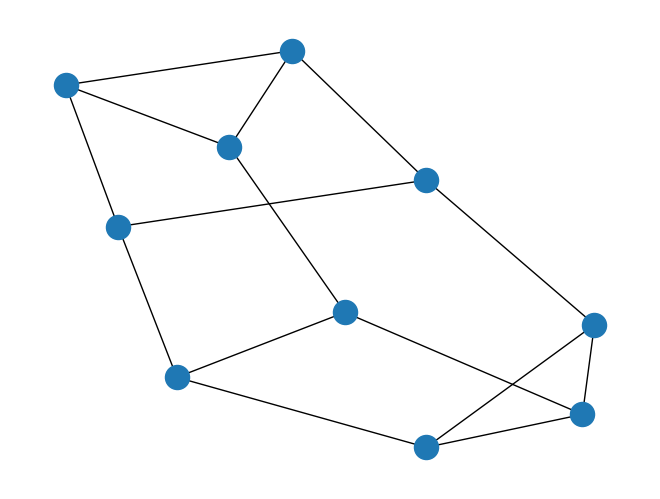

In [2]:
G = createGraph(10)
nx.draw(G)

Number of gates: 55


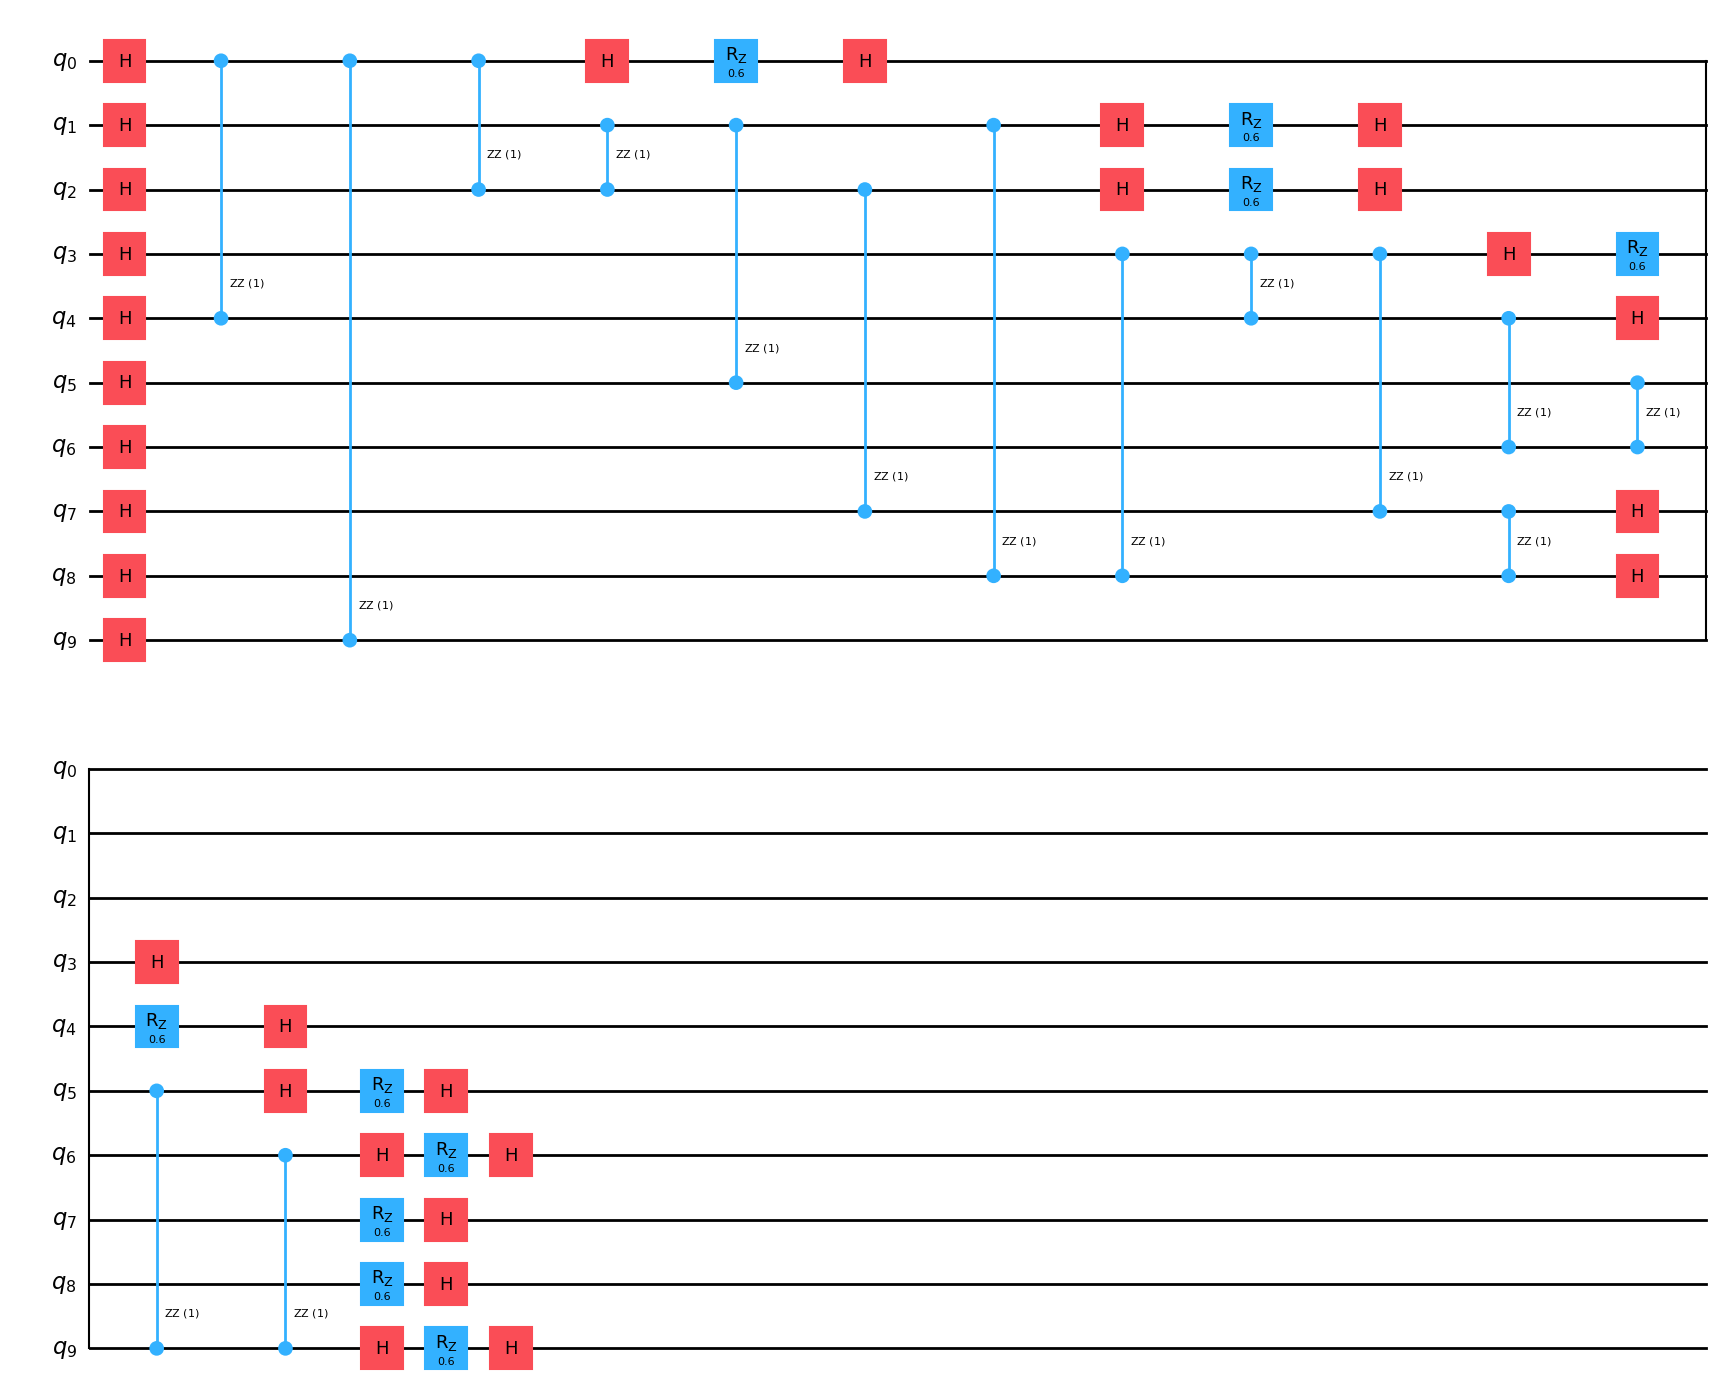

In [3]:
circuit = convertToCircuit(G)
print(f"Number of gates: {len(circuit.data)}")
circuit.draw('mpl')

Number of nodes: 80
Number of edges: 130


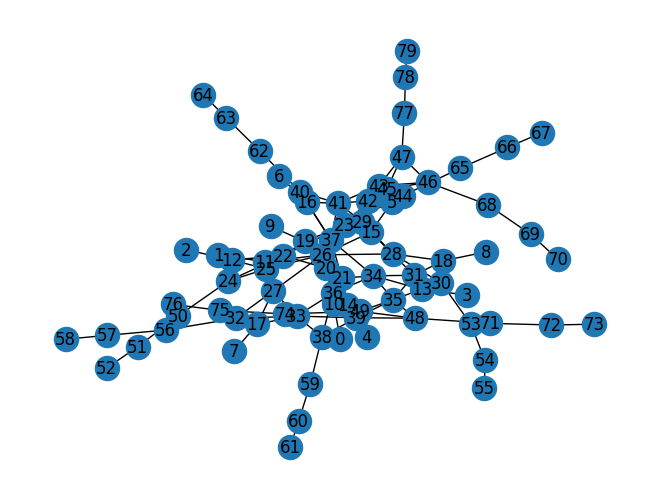

In [4]:
LG = convertToLineGraph(circuit)
nx.draw(LG, with_labels=True)
print(f"Number of nodes: {LG.number_of_nodes()}")
print(f"Number of edges: {LG.number_of_edges()}")

In [5]:
order, widths, c_width = rgreedy(LG, 0.05, 50)
newOrder, newWidths, newCWidth, optimalS, toSlice = findOptimalS(LG, widths, order, r=3)

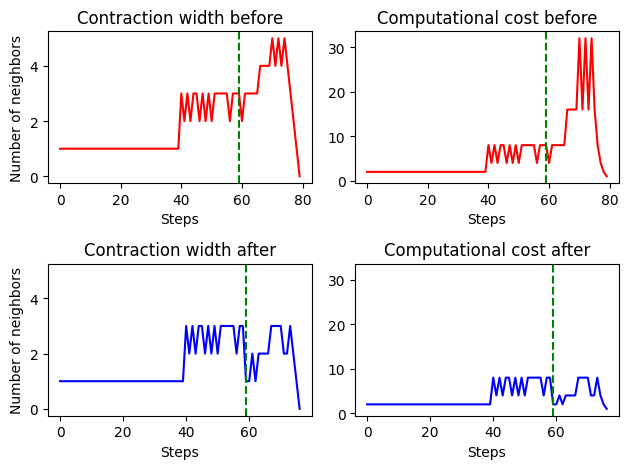

In [6]:
plotComparison(widths, newWidths, optimalS)

In [7]:
print(f"Contraction width was {c_width} now it's {newCWidth} with optimal step S = {optimalS}")
print(f"Computational cost was {math.exp2(c_width)}, now it's {math.exp2(newCWidth)} which is a reduction of {math.exp2(c_width)/math.exp2(newCWidth)}")

Contraction width was 5 now it's 3 with optimal step S = 59
Computational cost was 32.0, now it's 8.0 which is a reduction of 4.0


In [8]:
stepDependentSlicing(LG, order, widths, n=9, r=3)

{59: [22, 23, 28], 0: [20, 21, 22], 69: [41, 31, 33]}